
#    Informe de miniproyecto 1 - Curso Técnicas de Deep Learning

#    Clasificación de MRI mediante Fine-Tuning Profundo con ResNet-50


**Autorres:** Nicolás Ávila Villa y Mauricio Rodríguez Aponte

**Fecha:** 7 de noviembre de 2025

Este cuaderno implementa un pipeline **limpio**, **reproducible** y **documentado** para el **micro-proyecto 1**.  
Se organiza en **dos capítulos**:

- **Capítulo 1: Datos.** Preparación y validación del dataset (pipeline de carga, split estratificado 80/10/10, chequeos, LR Finder, ejemplos).
- **Capítulo 2: Modelo.** Arquitectura (ResNet50), entrenamiento (ReduceLROnPlateau + EarlyStopping), evaluación y análisis (curvas, matrices, ROC/PR, Grad-CAM, muestra balanceada + tabla).

> **Notas clave**  
> - Se trabaja con **3 canales** (replicación a RGB) para aprovechar pesos preentrenados.  
> - **Scheduler:** `ReduceLROnPlateau`.  
> - **LR Finder:** se usa para elegir el **LR inicial** del optimizador. En este cuaderno ya esta configurado el LR optimo hayado en la funsión ***lr_range_test*** (`1e-5`).
> - **Modo seguro** activado por defecto: `num_workers=0`, `pin_memory=False`.

#### **Guía rápida de ejecución del cuaderno**

1. Verifica que el dataset esté organizado en carpetas por clase y actualiza la ruta en `cfg.data_dir`.
2. Opcional: Ejecuta las celdas del **Capítulo 1** en orden hasta el bloque del *LR Finder* para preparar datos, modelo y calcular la tasa de aprendizaje recomendada **(El valor optimo ya esta configurado en el parámetro `base_lr`)**.
3. Si lo deseas, actualiza `cfg.base_lr` con el valor sugerido.
4. Ejecuta `main(cfg)` en el **Capítulo 2** para entrenar el modelo, validarlo y guardar todos los resultados.
5. Finalmente, ejecuta las secciones de **Consolidación** y **Análisis** para generar métricas, reportes visuales y mapas Grad-CAM.

Todos los artefactos y gráficos se guardan automáticamente en `outputs/<run>_<timestamp>/`.

## Capítulo 1 — Datos

### 1.1. Imports y configuración de entorno

In [2]:

# @title Imports & Safe runtime (ejecutar primero)
# -*- coding: utf-8 -*-
"""Imports y configuración general.

Incluye:
- Librerías base y de visión con PyTorch.
- Limpieza de memoria y sharing strategy (ambientes con /dev/shm limitado).
- Estilo Google en docstrings de clases y funciones a continuación.
"""
import os
import gc
import csv
import math
import time
import json
import random
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# Opcional: scikit-learn para splits estratificados y algunas métricas
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Pandas para tablas (comparación predicho vs real)
import pandas as pd

# ---- Modo seguro para entornos con memoria compartida limitada ----
try:
    torch.multiprocessing.set_sharing_strategy("file_system")
except Exception:
    pass

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


0

### 1.2. Configuración (dataclass)
Este bloque centraliza la configuración del experimento mediante una clase Config para garantizar la reproducibilidad y trazabilidad.Agrupa hiperparámetros esenciales y rutas, incluyendo:
* Datos y Salida (rutas).Hardware (selección automática GPU/CPU).Entrenamiento (épocas, base_lr, weight_decay).
* Scheduler (ReduceLROnPlateau para ajuste dinámico de $\alpha$).Reproducibilidad (fijación de semilla).
* LR Finder (rangos para optimización automática de $\alpha$).Establece un entorno controlado para consistencia, comparabilidad y fácil replicación del experimento.

In [3]:

# @title Configuración global (editar aquí los hiperparámetros principales)
# -*- coding: utf-8 -*-
"""Configuración general del experimento.

Atributos:
  data_dir: Ruta a la carpeta raíz con subcarpetas por clase (ImageFolder).
  out_dir: Carpeta de salida para artefactos.
  run_name: Nombre base del experimento (se usará un timestamp para la carpeta).

  device: Dispositivo de cómputo ("cuda" o "cpu").
  num_workers: Num. de workers para DataLoader (0 por modo seguro).
  pin_memory: Si fija páginas de memoria (False por modo seguro).
  batch_size: Tamaño de batch para DataLoader.
  seed: Semilla de reproducibilidad.

  epochs: Épocas máximas de entrenamiento.
  base_lr: Learning rate inicial (se puede ajustar con LR Finder).
  weight_decay: Penalización L2.

  sched_mode: Modo del ReduceLROnPlateau ('min' o 'max').
  sched_factor: Factor de reducción de LR.
  sched_patience: Paciencia (epochs sin mejora) del scheduler.

  lrfind_*: Parámetros del LR 
    (subset, iteraciones, rango).
"""
@dataclass
class Config:
    data_dir: str = "./data_set"
    out_dir: str = "./outputs"
    run_name: str = "resnet50_mri_ft"

    # Hardware (modo seguro ON por defecto)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0
    pin_memory: bool = False
    batch_size: int = 32
    seed: int = 42

    # Entrenamiento
    epochs: int = 20
    base_lr: float = 1e-5 # Learning rate inicial del optimizador identificado con LR Finder
    weight_decay: float = 1e-4

    # Scheduler: ReduceLROnPlateau
    sched_mode: str = "min"
    sched_factor: float = 0.5
    sched_patience: int = 2

    # LR Finder
    lrfind_subset: int = 500
    lrfind_iters: int = 100
    lrfind_start: float = 1e-6
    lrfind_end: float = 5e-2

cfg = Config()
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True)


### 1.3. Transformaciones
Este código define las transformaciones de entrada para hacer las imágenes compatibles con los pesos preentrenados de ResNet-50 (entrenado en ImageNet).Los pasos clave son:
* Conversión a RGB (de escala de grises): La conversión a RGB permite que las imágenes en escala de grises sean compatibles con la arquitectura preentrenada de ResNet-50, la cual espera tres canales de entrada. Esto evita modificar la estructura original del modelo y conserva los pesos aprendidos en ImageNet, facilitando la transferencia de conocimiento y mejorando la eficiencia y el rendimiento del entrenamiento en el microproyecto.
* Redimensionamiento a $224 \times 224$: Ajusta al tamaño de entrada estándar.
* Normalización (con medias y desviaciones de ImageNet): Mantiene la escala estadística original para aprovechar el conocimiento aprendido.En conjunto, esto crea una base coherente y esencial para el fine-tuning de ResNet-50.

In [4]:

# @title Transformaciones baseline
# -*- coding: utf-8 -*-
"""Transformaciones consistentes con ImageNet (para pesos preentrenados).

Se convierte a RGB (3 canales), se redimensiona a 224x224 y se normaliza con
las medias y desviaciones estándar de ImageNet.
"""
IMG_SIZE = (224, 224)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

to_rgb = transforms.Lambda(lambda x: x.convert("RGB"))

train_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    to_rgb,
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_tfms = train_tfms


### 1.4. DataModule (ImageFolder + split estratificado 80/10/10)
Este código organiza la carga de datos de forma estructurada y reproducible. Implementa una división **estratificada 80/10/10** para asegurar que todas las clases mantengan la misma proporción en entrenamiento, validación y prueba, evitando sesgos. Usa `ImageFolder` y `Subset` para no mover archivos físicos. Centralizarlo en un `DataModule` permite separar la lógica de datos del modelo, mejorar la trazabilidad y facilitar la replicación del experimento.

In [5]:

# @title DataModule
# -*- coding: utf-8 -*-
class DataModule:
    """Encapsula carga, splits y DataLoaders.

    Usa `ImageFolder` y realiza una división **estratificada** 80/10/10 sin mover archivos
    (se trabaja con índices).

    Atributos:
      cfg: Configuración global.
      idx_to_class: Mapeo de índice -> nombre de clase.
      _train, _val, _test: Subsets para cada split.

    Métodos:
      setup: Prepara datasets y splits.
      loaders: Retorna DataLoaders para train/val/test.

    """
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.idx_to_class = {}
        self._train = self._val = self._test = None

    def setup(self) -> None:
        """Carga el dataset y crea splits estratificados 80/10/10."""
        base_ds = datasets.ImageFolder(self.cfg.data_dir, transform=train_tfms)
        self.idx_to_class = {i: c for c, i in base_ds.class_to_idx.items()}
        targets = np.array([y for _, y in base_ds.samples])

        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=self.cfg.seed)
        train_idx, temp_idx = next(sss.split(np.zeros(len(targets)), targets))

        y_temp = targets[temp_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=self.cfg.seed)
        val_rel, test_rel = next(sss2.split(np.zeros(len(y_temp)), y_temp))
        val_idx = temp_idx[val_rel]
        test_idx = temp_idx[test_rel]

        self._train = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=train_tfms), train_idx)
        self._val   = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=test_tfms),  val_idx)
        self._test  = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=test_tfms),  test_idx)

    def loaders(self):
        """Construye DataLoaders para train/val/test.

        Returns:
          Tuple[DataLoader, DataLoader, DataLoader]: loaders de train, val y test.
        """
        mk = lambda ds, sh: DataLoader(
            ds, batch_size=self.cfg.batch_size, shuffle=sh,
            num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
        )
        return mk(self._train, True), mk(self._val, False), mk(self._test, False)


### 1.5. Chequeos de split y 5 imágenes del set de entrenamiento (transformadas)
Este código verifica que la división estratificada del conjunto de datos sea correcta y balanceada. Muestra el tamaño de cada partición y la distribución de clases en entrenamiento, validación y prueba, garantizando que no haya sesgos. Además, visualiza ejemplos transformados para confirmar que las imágenes fueron cargadas y normalizadas adecuadamente. Estos chequeos aseguran la calidad y coherencia de los datos antes del entrenamiento del modelo.

Sizes -> train: 5618 | val: 702 | test: 703
Class mapping: {0: 'glioma', 1: 'healthy', 2: 'meningioma', 3: 'pituitary'}
Train dist.: {'glioma': 1297, 'healthy': 1600, 'meningioma': 1316, 'pituitary': 1405}
Val dist.  : {'glioma': 162, 'healthy': 200, 'meningioma': 164, 'pituitary': 176}
Test dist. : {'glioma': 162, 'healthy': 200, 'meningioma': 165, 'pituitary': 176}
✅ Imagen guardada en: ./outputs/imagenes_de_ejemplo.png


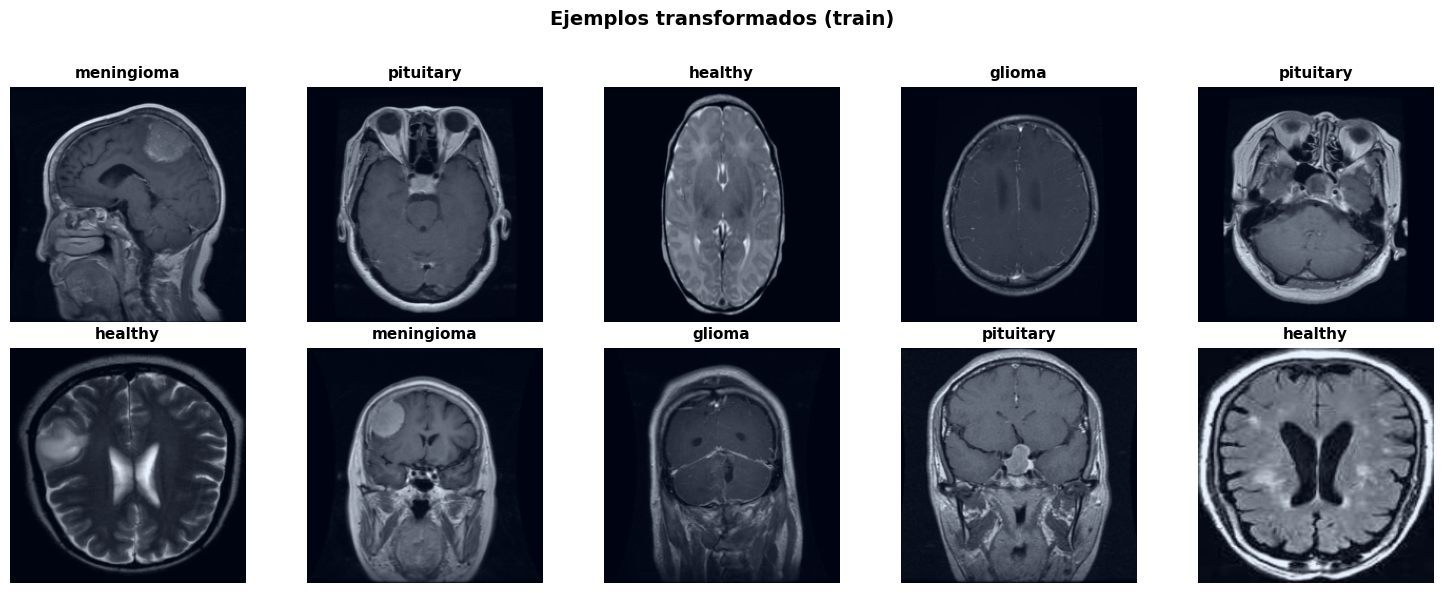

In [6]:

# @title Chequeos de split + muestras visuales del train
# -*- coding: utf-8 -*-
def _split_counts(subset: Subset) -> dict:
    base_targets = np.array(subset.dataset.targets)
    idxs = np.array(subset.indices)
    cnt = Counter(base_targets[idxs])
    return {int(k): int(v) for k, v in cnt.items()}

dm = DataModule(cfg)
dm.setup()
train_loader, val_loader, test_loader = dm.loaders()

print(f"Sizes -> train: {len(train_loader.dataset)} | val: {len(val_loader.dataset)} | test: {len(test_loader.dataset)}")
print("Class mapping:", dm.idx_to_class)
print("Train dist.:", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(train_loader.dataset).items())})
print("Val dist.  :", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(val_loader.dataset).items())})
print("Test dist. :", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(test_loader.dataset).items())})

# Visualizar 10 imágenes transformadas del train
# Configuración para alta calidad
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
sample_ids = random.sample(range(len(train_loader.dataset)), min(10, len(train_loader.dataset)))

for ax, idx in zip(axes, sample_ids):
    img, y = train_loader.dataset[idx]
    # Normalizar a [0,1] para visualización
    arr = img.permute(1, 2, 0).numpy()
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    ax.imshow(arr, cmap='gray' if arr.shape[2] == 1 else None)
    ax.set_title(dm.idx_to_class[y], fontsize=11, fontweight='bold')
    ax.axis("off")

plt.suptitle("Ejemplos transformados (train)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar
output_path = os.path.join(cfg.out_dir, "imagenes_de_ejemplo.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"✅ Imagen guardada en: {output_path}")
plt.show()


### 1.6. LR Finder (subset=500, iteraciones=100)
Este código aplica el método **Learning Rate Finder**, propuesto por Smith (2015/2017), para identificar de forma empírica la tasa de aprendizaje que acelera la convergencia sin causar inestabilidad. Evalúa cómo varía la pérdida al incrementar progresivamente el *learning rate* y sugiere un valor óptimo. Esto mejora la eficiencia del entrenamiento y evita depender de prueba y error, aportando rigor y reproducibilidad al microproyecto.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 394MB/s]


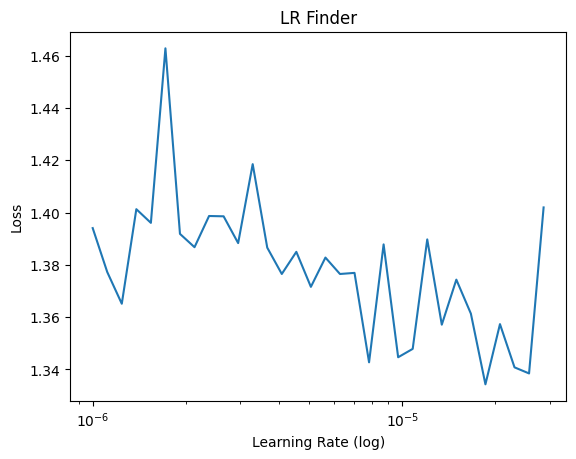

Sugerencia de LR inicial ≈ 1.20e-05  -> Asigna manualmente a cfg.base_lr si deseas.


In [6]:

# @title LR Finder
# -*- coding: utf-8 -*-
def lr_range_test(model: nn.Module, dataloader: DataLoader,
                  start_lr: float, end_lr: float, num_iters: int):
    """Ejecuta un LR range test (Smith, 2015/2017).

    Args:
      model: Red a evaluar (con cabeza final correcta).
      dataloader: Loader de un subset de entrenamiento.
      start_lr: LR inicial del barrido.
      end_lr: LR final del barrido (escala log).
      num_iters: Número de iteraciones a muestrear.

    Returns:
      Tuple[np.ndarray, np.ndarray]: (lrs, losses)
    """
    lrs, losses = [], []
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    criterion = nn.CrossEntropyLoss()
    lr_lambda = lambda it: (end_lr/start_lr) ** (it / max(1, num_iters))

    model.train()
    it = 0
    for images, targets in dataloader:
        if it >= num_iters:
            break
        # Actualizar LR progresivamente
        lr = start_lr * ((end_lr/start_lr) ** (it / max(1, num_iters)))
        for g in optimizer.param_groups:
            g['lr'] = lr

        images, targets = images.to(cfg.device), targets.to(cfg.device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        lrs.append(lr); losses.append(loss.item()); it += 1

    return np.array(lrs), np.array(losses)

def _build_model_for_lrfind(num_classes: int) -> nn.Module:
    """Construye ResNet50 con cabeza final de num_classes para LR Finder."""
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    return m.to(cfg.device)

subset_size = min(cfg.lrfind_subset, len(train_loader.dataset))
subset_idx = random.sample(range(len(train_loader.dataset)), subset_size)
subset_loader = DataLoader(
    Subset(train_loader.dataset, subset_idx),
    batch_size=min(cfg.batch_size, 16),
    shuffle=True, num_workers=0, pin_memory=False
)

model_tmp = _build_model_for_lrfind(num_classes=len(dm.idx_to_class))
lrs, losses = lr_range_test(model_tmp, subset_loader,
                            cfg.lrfind_start, cfg.lrfind_end, cfg.lrfind_iters)

plt.figure()
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("Learning Rate (log)")
plt.ylabel("Loss")
plt.title("LR Finder")
plt.show()


loss_s = np.convolve(losses, np.ones(5)/5, mode='valid')
best_i = int(np.argmin(loss_s)) if loss_s.size > 0 else 0
suggested_lr = float(lrs[max(0, best_i-3)]) if lrs.size > 0 else cfg.base_lr
print(f"Sugerencia de LR inicial ≈ {suggested_lr:.2e}  -> Asigna manualmente a cfg.base_lr si deseas.")


## Capítulo 2 — Modelo

### 2.1. ModelBuilder (ResNet50 → 4 clases)
Este código construye una **ResNet-50 preentrenada** y adapta su capa final para clasificar las cuatro clases del microproyecto. Reutilizar los pesos de ImageNet permite aprovechar características visuales ya aprendidas, reduciendo el tiempo de entrenamiento y mejorando la precisión con pocos datos. Modificar solo la capa final ajusta el modelo al nuevo dominio manteniendo la arquitectura y los beneficios del aprendizaje por transferencia.


In [7]:

# @title ModelBuilder
# -*- coding: utf-8 -*-
class ModelBuilder:
    """Crea el modelo ResNet50 con cabeza para 4 clases.

    Args:
      cfg: Configuración global.
      num_classes: Número de clases (4 en este microproyecto).

    Returns:
      nn.Module: Modelo listo para entrenamiento en cfg.device.
    """
    def __init__(self, cfg: Config, num_classes: int):
        self.cfg = cfg
        self.num_classes = num_classes

    def build(self) -> nn.Module:
        """Instancia ResNet50 preentrenada (ImageNet) y sustituye la FC final."""
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, self.num_classes)
        return m.to(self.cfg.device)


### 2.2. Trainer (ReduceLROnPlateau + EarlyStopping)
Este código implementa el proceso completo de entrenamiento y validación del modelo. Usa **CrossEntropyLoss** por ser la función estándar en clasificación multiclase. El **EarlyStopping** evita sobreajuste deteniendo el entrenamiento cuando no hay mejora. El **scheduler ReduceLROnPlateau** ajusta automáticamente la tasa de aprendizaje para estabilizar la convergencia. Además, calcula métricas clave como **accuracy** y **macro-F1**, garantizando una evaluación equilibrada entre clases.


In [8]:

# @title Trainer
# -*- coding: utf-8 -*-
def criterion_fn() -> nn.Module:
    """Devuelve la función de pérdida para clasificación."""
    return nn.CrossEntropyLoss()

class EarlyStopper:
    """Detiene el entrenamiento si no hay mejora en validación.

    Args:
      patience: Número de epochs sin mejora permitidos.
      mode: 'min' para pérdida, 'max' para métrica.

    Métodos:
      step(value): Retorna True si se agotó la paciencia; False en caso contrario.
    """
    def __init__(self, patience: int = 5, mode: str = "min"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.bad = 0

    def step(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            self.bad = 0
            return False

        improved = (value < self.best) if self.mode == "min" else (value > self.best)
        if improved:
            self.best = value
            self.bad = 0
            return False

        self.bad += 1
        return self.bad >= self.patience

class Trainer:
    """Entrenador con logging básico y scheduler ReduceLROnPlateau."""
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def _epoch(self, model: nn.Module, loader: DataLoader,
               criterion: nn.Module, optimizer: torch.optim.Optimizer = None):
        """Ejecuta una época de entrenamiento o validación.

        Args:
          model: Red a entrenar/evaluar.
          loader: DataLoader del split correspondiente.
          criterion: Función de pérdida.
          optimizer: Optimizador (si None, modo validación).

        Returns:
          Tuple[float, float, float]: (loss_prom, acc, macro_f1)
        """
        train_mode = optimizer is not None
        model.train() if train_mode else model.eval()

        total = 0
        loss_sum = 0.0
        correct = 0
        # Cálculo de macro-F1 manual (para evitar dependencias)
        f1_counts = {c: {'tp': 0, 'fp': 0, 'fn': 0} for c in range(4)}

        with torch.set_grad_enabled(train_mode):
            for images, targets in loader:
                images, targets = images.to(self.cfg.device), targets.to(self.cfg.device)
                if train_mode:
                    optimizer.zero_grad(set_to_none=True)
                logits = model(images)
                loss = criterion(logits, targets)
                if train_mode:
                    loss.backward()
                    optimizer.step()

                loss_sum += loss.item() * images.size(0)
                total += images.size(0)

                preds = logits.argmax(1)
                correct += (preds == targets).sum().item()

                for c in range(4):
                    tp = ((preds == c) & (targets == c)).sum().item()
                    fp = ((preds == c) & (targets != c)).sum().item()
                    fn = ((preds != c) & (targets == c)).sum().item()
                    f1_counts[c]['tp'] += tp
                    f1_counts[c]['fp'] += fp
                    f1_counts[c]['fn'] += fn

        loss_avg = loss_sum / max(1, total)
        acc = correct / max(1, total)

        f1s = []
        for c in f1_counts:
            tp, fp, fn = f1_counts[c]['tp'], f1_counts[c]['fp'], f1_counts[c]['fn']
            prec = tp / (tp + fp + 1e-12) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn + 1e-12) if (tp + fn) > 0 else 0.0
            f1 = 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s))

        return loss_avg, acc, macro_f1

    def fit(self, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader):
        """Entrena el modelo con early stopping y ReduceLROnPlateau."""
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.base_lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode=cfg.sched_mode, factor=cfg.sched_factor,
            patience=cfg.sched_patience, verbose=True
        )
        early = EarlyStopper(patience=5, mode="min")
        history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
        best_w = None
        best_val = float("inf")

        for ep in range(1, cfg.epochs + 1):
            tr_loss, _, _ = self._epoch(model, train_loader, criterion_fn(), optimizer)
            val_loss, val_acc, val_f1 = self._epoch(model, val_loader, criterion_fn(), optimizer=None)
            scheduler.step(val_loss)

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_f1"].append(val_f1)

            print(f"Epoch {ep:03d}/{cfg.epochs} | "
                  f"train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | "
                  f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

            if val_loss < best_val:
                best_val = val_loss
                best_w = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            if early.step(val_loss):
                print("Early stopping activado.")
                break

        if best_w is not None:
            model.load_state_dict(best_w)

        # Guardar mejor checkpoint e historia
        torch.save(model.state_dict(), os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth"))
        np.save(os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy"), history, allow_pickle=True)
        return model, history

    def validate(self, model: nn.Module, loader: DataLoader):
        """Evalúa un modelo en un DataLoader y retorna métricas básicas."""
        return self._epoch(model, loader, criterion_fn(), optimizer=None)


### 2.3. ExperimentLogger (artefactos y figuras centralizadas)
Este código gestiona el registro completo del experimento, garantizando trazabilidad y reproducibilidad. Guarda configuraciones, métricas, particiones y resultados en una carpeta única por corrida. Permite reconstruir el entorno, comparar ejecuciones y documentar los resultados con evidencia visual. Centralizar el registro facilita el análisis, la validación científica y la replicabilidad de los hallazgos del microproyecto.


In [9]:

# @title ExperimentLogger
# -*- coding: utf-8 -*-
class ExperimentLogger:
    """Logger minimalista sobre disco para consolidar un experimento.

    Crea una carpeta única por corrida: `outputs/<run_name>_<timestamp>/`
    y mantiene un alias `<run_name>_latest` (symlink si el SO lo permite).

    Guarda:
      - config.json, classes.json, split_sizes.json, split_indices.json
      - history.npy, history.csv, curves.png, val_metrics.png
      - test_metrics.json, test_confusion_matrix.png
      - requirements.freeze.txt (snapshot aproximado del entorno)
      - (Opcional) lr_finder.png
    """
    def __init__(self, cfg: Config, idx_to_class: dict = None, run_dir: str = None):
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        base = Path(cfg.out_dir)
        base.mkdir(parents=True, exist_ok=True)
        self.run_dir = Path(run_dir) if run_dir else base / f"{cfg.run_name}_{ts}"
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.cfg = cfg
        self.idx_to_class = idx_to_class or {}

        latest = base / f"{cfg.run_name}_latest"
        if latest.exists() and latest.is_symlink():
            latest.unlink()
        try:
            latest.symlink_to(self.run_dir, target_is_directory=True)
        except Exception:
            pass

    # ---- Config & Data ----
    def save_config(self) -> None:
        with open(self.run_dir / "config.json", "w") as f:
            json.dump(asdict(self.cfg), f, indent=2, default=str)

    def save_class_map(self, class_to_idx: dict = None, idx_to_class: dict = None) -> None:
        if class_to_idx is None and idx_to_class is None:
            idx_to_class = self.idx_to_class
            class_to_idx = {v: k for k, v in idx_to_class.items()}
        if idx_to_class is None:
            idx_to_class = {v: k for k, v in class_to_idx.items()}
        with open(self.run_dir / "classes.json", "w") as f:
            json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, f, indent=2)

    def save_split_indices(self, train_subset: Subset, val_subset: Subset, test_subset: Subset) -> None:
        def get_idx(subset):
            return list(map(int, getattr(subset, "indices", [])))
        payload = {
            "train_indices": get_idx(train_subset),
            "val_indices": get_idx(val_subset),
            "test_indices": get_idx(test_subset),
        }
        with open(self.run_dir / "split_indices.json", "w") as f:
            json.dump(payload, f, indent=2)

    def save_split_sizes(self, train_loader: DataLoader, val_loader: DataLoader, test_loader: DataLoader) -> None:
        sizes = {
            "train": len(train_loader.dataset),
            "val": len(val_loader.dataset),
            "test": len(test_loader.dataset),
            "total": sum([len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)]),
        }
        with open(self.run_dir / "split_sizes.json", "w") as f:
            json.dump(sizes, f, indent=2)

    # ---- History ----
    def save_history(self, history: dict) -> None:
        np.save(self.run_dir / "history.npy", history, allow_pickle=True)
        # CSV
        keys = list(history.keys())
        with open(self.run_dir / "history.csv", "w", newline="") as f:
            wr = csv.writer(f)
            wr.writerow(["epoch"] + keys)
            for i in range(len(history[keys[0]])):
                row = [i + 1] + [history[k][i] for k in keys]
                wr.writerow(row)

    def plot_curves(self, history: dict, filename: str = "curves.png") -> None:
        plt.figure()
        if "train_loss" in history:
            plt.plot(history["train_loss"], label="train_loss")
        if "val_loss" in history:
            plt.plot(history["val_loss"], label="val_loss")
        plt.title("Loss curves"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()

        if "val_acc" in history or "val_f1" in history:
            plt.figure()
            if "val_acc" in history:
                plt.plot(history["val_acc"], label="val_acc")
            if "val_f1" in history:
                plt.plot(history["val_f1"], label="val_macro_f1")
            plt.title("Validation metrics"); plt.legend(); plt.xlabel("epoch")
            plt.savefig(self.run_dir / "val_metrics.png", bbox_inches="tight", dpi=150)
            plt.close()

    # ---- Test eval ----
    @torch.no_grad()
    def evaluate_and_save(self, model: nn.Module, loader: DataLoader, criterion: nn.Module,
                          idx_to_class: dict = None, file_prefix: str = "test") -> dict:
        device = next(model.parameters()).device
        model.eval()
        all_logits, all_targets = [], []
        running_loss = 0.0
        n = 0

        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            running_loss += loss.item() * images.size(0)
            n += images.size(0)
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

        loss_avg = running_loss / max(1, n)
        logits = torch.cat(all_logits, dim=0)
        targets = torch.cat(all_targets, dim=0)
        preds = logits.argmax(dim=1)
        acc = (preds == targets).float().mean().item()

        # macro-F1 manual
        num_classes = int(logits.shape[1])
        f1s = []
        for c in range(num_classes):
            tp = ((preds == c) & (targets == c)).sum().item()
            fp = ((preds == c) & (targets != c)).sum().item()
            fn = ((preds != c) & (targets == c)).sum().item()
            prec = tp / (tp + fp + 1e-12) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn + 1e-12) if (tp + fn) > 0 else 0.0
            f1 = 0.0 if (prec + rec) == 0 else (2 * prec * rec) / (prec + rec)
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s))

        metrics = {"loss": float(loss_avg), "acc": float(acc), "macro_f1": float(macro_f1)}
        with open(self.run_dir / f"{file_prefix}_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

        cm = confusion_matrix(targets.numpy(), preds.numpy(), labels=list(range(num_classes)))
        labels = [ (idx_to_class or self.idx_to_class).get(i, str(i)) for i in range(num_classes) ]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(5, 5))
        disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
        plt.title(f"Confusion Matrix – {file_prefix.upper()}")
        plt.tight_layout()
        fig.savefig(self.run_dir / f"{file_prefix}_confusion_matrix.png", dpi=150)
        plt.close(fig)
        return metrics

    # ---- Checkpoint & Env ----
    def note_checkpoint(self, ckpt_path: str) -> None:
        with open(self.run_dir / "checkpoint.txt", "w") as f:
            f.write(str(Path(ckpt_path).resolve()))

    def freeze_requirements(self) -> None:
        try:
            import pkg_resources
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                for dist in sorted(pkg_resources.working_set, key=lambda d: d.project_name.lower()):
                    f.write(f"{dist.project_name}=={dist.version}\n")
        except Exception as e:
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                f.write(f"# pkg_resources unavailable: {e}\n")

    # ---- LR Finder figure ----
    def save_lr_finder(self, lrs: np.ndarray, losses: np.ndarray, filename: str = "lr_finder.png") -> None:
        if lrs is None or losses is None or len(lrs) == 0:
            return
        plt.figure()
        plt.plot(lrs, losses)
        plt.xscale("log")
        plt.xlabel("Learning Rate (log)")
        plt.ylabel("Loss")
        plt.title("LR Range Test")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()


### 2.4. `main(cfg)` — Entrenamiento y logging principal
Este código integra y ejecuta todo el flujo del experimento de forma ordenada y reproducible. Coordina la carga de datos, construcción del modelo, entrenamiento con control de aprendizaje y evaluación final. Además, centraliza el registro de configuraciones, métricas y artefactos. Su propósito es garantizar que el proceso completo sea trazable, coherente y fácil de replicar, cumpliendo los estándares de un experimento científico en deep learning.


In [10]:

# @title main(cfg)
# -*- coding: utf-8 -*-
def main(cfg: Config):
    """Ejecuta el ciclo de entrenamiento y registro del experimento.

    Flujo:
      1) Prepara DataModule (train/val/test) y modelo.
      2) Entrena con Trainer (ReduceLROnPlateau + EarlyStopping).
      3) Evalúa en test.
      4) Registra artefactos con ExperimentLogger.
    """
    # Datos
    dm = DataModule(cfg)
    dm.setup()
    train_loader, val_loader, test_loader = dm.loaders()

    # Modelo
    builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
    model = builder.build()

    # Entrenamiento
    trainer = Trainer(cfg)
    model, history = trainer.fit(model, train_loader, val_loader)

    # Evaluación en test
    test_loss, test_acc, test_f1 = trainer.validate(model, test_loader)
    print(f"TEST | loss={test_loss:.4f} | acc={test_acc:.4f} | macro_f1={test_f1:.4f}")

    # Logging consolidado
    logger = ExperimentLogger(cfg, idx_to_class=dm.idx_to_class)
    logger.save_config()
    logger.save_class_map()
    logger.save_split_sizes(train_loader, val_loader, test_loader)
    logger.save_split_indices(train_loader.dataset, val_loader.dataset, test_loader.dataset)
    logger.freeze_requirements()
    logger.save_history(history)
    logger.plot_curves(history)
    logger.note_checkpoint(os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth"))
    _ = logger.evaluate_and_save(model, test_loader, criterion_fn(),
                                 idx_to_class=dm.idx_to_class, file_prefix="test")

# Para ejecutar entrenamiento                        :
main(cfg)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 408MB/s]


Epoch 001/20 | train_loss=0.9859 | val_loss=0.5014 | val_acc=0.8932 | val_f1=0.8901
Epoch 002/20 | train_loss=0.3646 | val_loss=0.2448 | val_acc=0.9316 | val_f1=0.9303
Epoch 003/20 | train_loss=0.2006 | val_loss=0.1717 | val_acc=0.9430 | val_f1=0.9416
Epoch 004/20 | train_loss=0.1216 | val_loss=0.1179 | val_acc=0.9687 | val_f1=0.9683
Epoch 005/20 | train_loss=0.0731 | val_loss=0.1014 | val_acc=0.9658 | val_f1=0.9652
Epoch 006/20 | train_loss=0.0478 | val_loss=0.0849 | val_acc=0.9744 | val_f1=0.9741
Epoch 007/20 | train_loss=0.0340 | val_loss=0.0743 | val_acc=0.9772 | val_f1=0.9765
Epoch 008/20 | train_loss=0.0227 | val_loss=0.0786 | val_acc=0.9729 | val_f1=0.9726
Epoch 009/20 | train_loss=0.0135 | val_loss=0.0846 | val_acc=0.9772 | val_f1=0.9770
Epoch 010/20 | train_loss=0.0125 | val_loss=0.0721 | val_acc=0.9729 | val_f1=0.9724
Epoch 011/20 | train_loss=0.0137 | val_loss=0.1202 | val_acc=0.9758 | val_f1=0.9755
Epoch 012/20 | train_loss=0.0078 | val_loss=0.0753 | val_acc=0.9772 | val_f1

### 2.5. Consolidación post-entrenamiento (sin reentrenar)
Este código permite reconstruir y registrar los resultados de una corrida previa sin repetir el entrenamiento. Recupera los artefactos esenciales —modelo, métricas, configuraciones e historia— para consolidar el experimento en disco. Garantiza trazabilidad, reproducibilidad y documentación completa, facilitando el análisis posterior y la verificación de resultados ya obtenidos en el microproyecto.


In [11]:

# @title Consolidar artefactos de una corrida ya existente
# -*- coding: utf-8 -*-
dm = DataModule(cfg)
dm.setup()
train_loader, val_loader, test_loader = dm.loaders()

logger = ExperimentLogger(cfg, idx_to_class=dm.idx_to_class)
logger.save_config()
logger.save_class_map()
logger.save_split_sizes(train_loader, val_loader, test_loader)
logger.save_split_indices(train_loader.dataset, val_loader.dataset, test_loader.dataset)
logger.freeze_requirements()

# Historia previa
hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
if os.path.exists(hist_path):
    history = np.load(hist_path, allow_pickle=True).item()
    logger.save_history(history)
    logger.plot_curves(history)

# Cargar mejor checkpoint y evaluar test
builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
model = builder.build().to(cfg.device)
best_ckpt = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
if os.path.exists(best_ckpt):
    state = torch.load(best_ckpt, map_location=cfg.device)
    model.load_state_dict(state)
    logger.note_checkpoint(best_ckpt)
    _ = logger.evaluate_and_save(model, test_loader, criterion_fn(),
                                 idx_to_class=dm.idx_to_class, file_prefix="test")
else:
    print("⚠️ No se encontró el checkpoint para consolidación:", best_ckpt)


### 2.6. Inferencia en test (y_true, y_pred, y_proba) para análisis
Este código genera y guarda las predicciones del modelo junto con las etiquetas reales y las probabilidades asociadas. Permite analizar el desempeño fuera del entrenamiento, calcular métricas y construir reportes o visualizaciones posteriores. Al conservar estos arreglos, se facilita la validación, el análisis de errores y la comparación objetiva entre distintas corridas del microproyecto.


In [12]:

# @title Generar y guardar y_true, y_pred, y_proba
# -*- coding: utf-8 -*-
analysis_dir = os.path.join(cfg.out_dir, "analysis")
os.makedirs(analysis_dir, exist_ok=True)

builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
model = builder.build().to(cfg.device)
best_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
assert os.path.exists(best_path), f"No existe el checkpoint: {best_path}"
model.load_state_dict(torch.load(best_path, map_location=cfg.device))
model.eval()

y_true, y_pred, y_proba = [], [], []

with torch.no_grad():
    for i in range(len(test_loader.dataset)):
        img, y = test_loader.dataset[i]
        logits = model(img.unsqueeze(0).to(cfg.device))
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        y_true.append(int(y))
        y_pred.append(int(np.argmax(probs)))
        y_proba.append(probs.astype(np.float32))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.vstack(y_proba)

np.save(os.path.join(analysis_dir, "y_true.npy"), y_true)
np.save(os.path.join(analysis_dir, "y_pred.npy"), y_pred)
np.save(os.path.join(analysis_dir, "y_proba.npy"), y_proba)

print("Listo: y_true, y_pred, y_proba guardados en ./outputs/analysis")
print(classification_report(y_true, y_pred, target_names=[dm.idx_to_class[i] for i in range(len(dm.idx_to_class))], digits=4))


Listo: y_true, y_pred, y_proba guardados en ./outputs/analysis
              precision    recall  f1-score   support

      glioma     0.9873    0.9568    0.9718       162
     healthy     0.9950    0.9900    0.9925       200
  meningioma     0.9412    0.9697    0.9552       165
   pituitary     0.9831    0.9886    0.9858       176

    accuracy                         0.9772       703
   macro avg     0.9766    0.9763    0.9763       703
weighted avg     0.9776    0.9772    0.9773       703



### 2.7. Matrices de confusión (conteos y normalizada)
Este código genera matrices de confusión absolutas y normalizadas para evaluar el desempeño del modelo por clase. Permite identificar qué tipos de tumores se confunden entre sí y medir la precisión de las predicciones en cada categoría. Guardar estas matrices facilita el análisis visual y comparativo de los errores, aportando evidencia clave sobre la calidad y consistencia del modelo en el microproyecto.


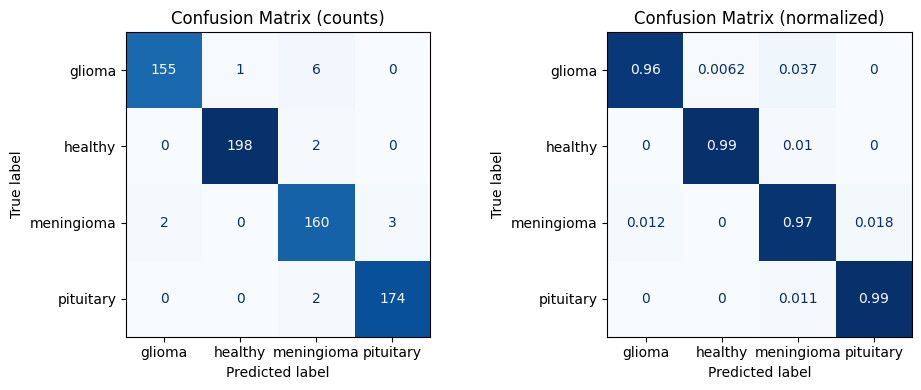

✅ Guardado: ./outputs/analysis/confusion_matrices.png


In [13]:

# @title Confusion matrices
# -*- coding: utf-8 -*-
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))
class_names = [dm.idx_to_class[i] for i in range(len(dm.idx_to_class))]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))), normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion Matrix (counts)")
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=ax[1], colorbar=False, cmap="Blues")
ax[1].set_title("Confusion Matrix (normalized)")
plt.tight_layout()
cm_path = os.path.join(analysis_dir, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado:", cm_path)


### 2.8. Curvas de entrenamiento (Loss / Métricas)
Este código visualiza la evolución del entrenamiento mediante las curvas de pérdida y métricas de validación. Permite analizar si el modelo converge adecuadamente, detectar sobreajuste y evaluar la estabilidad del aprendizaje. Guardar estas gráficas facilita documentar el comportamiento del modelo y respaldar los resultados cuantitativos del microproyecto con evidencia visual.


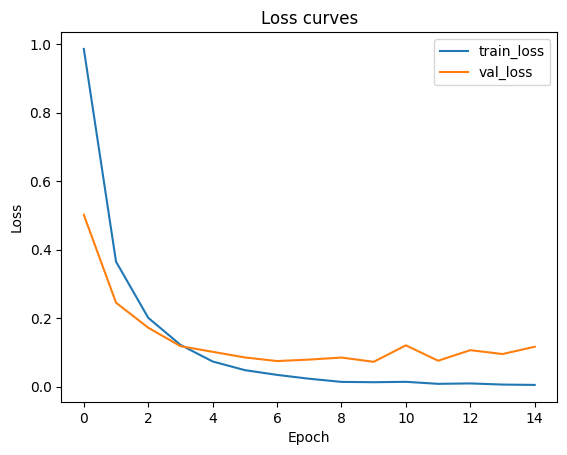

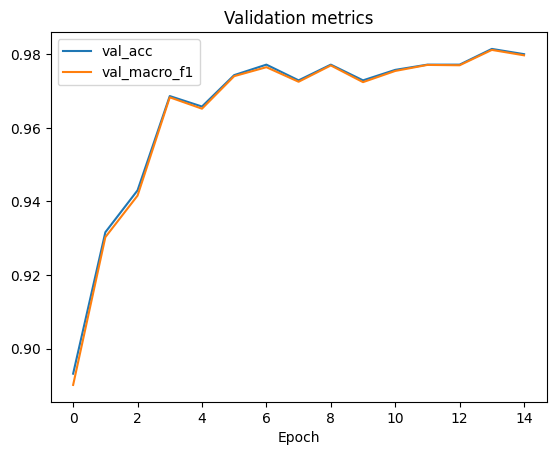

✅ Guardados: ./outputs/analysis/curves_loss.png y ./outputs/analysis/curves_val_metrics.png


In [14]:

# @title Curvas de entrenamiento
# -*- coding: utf-8 -*-
hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
assert os.path.exists(hist_path), f"No existe {hist_path}"
history = np.load(hist_path, allow_pickle=True).item()

plt.figure()
plt.plot(history.get("train_loss", []), label="train_loss")
plt.plot(history.get("val_loss", []), label="val_loss")
plt.title("Loss curves"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
p1 = os.path.join(analysis_dir, "curves_loss.png")
plt.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()

plt.figure()
if "val_acc" in history: plt.plot(history["val_acc"], label="val_acc")
if "val_f1" in history:  plt.plot(history["val_f1"],  label="val_macro_f1")
plt.title("Validation metrics"); plt.xlabel("Epoch"); plt.legend()
p2 = os.path.join(analysis_dir, "curves_val_metrics.png")
plt.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()

print("✅ Guardados:", p1, "y", p2)


### 2.9. Curvas ROC y Precision-Recall (One-vs-Rest)
Este código evalúa el rendimiento del modelo por clase usando curvas ROC y Precision-Recall en formato *one-vs-rest*. Estas gráficas permiten medir la capacidad del modelo para distinguir entre clases y su comportamiento ante distintos umbrales de decisión. Los valores AUC y AP cuantifican la calidad de las predicciones. Guardar estas curvas aporta un análisis detallado y visual de la discriminación y precisión alcanzadas en el microproyecto.


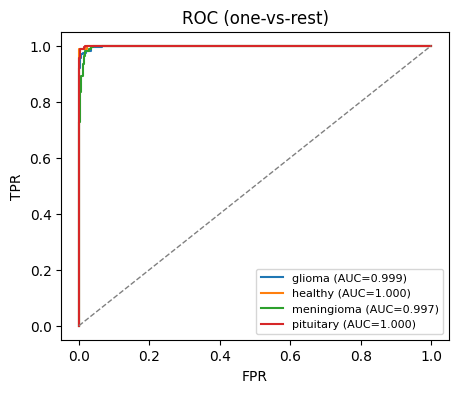

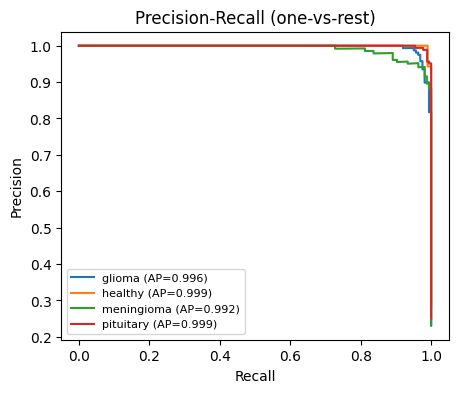

✅ Guardados: ./outputs/analysis/roc_multiclass.png y ./outputs/analysis/pr_multiclass.png


In [15]:

# @title ROC y Precision-Recall (OvR)
# -*- coding: utf-8 -*-
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_proba = np.load(os.path.join(analysis_dir, "y_proba.npy"))
n_classes = len(class_names)

# binarizar
Y = np.zeros((y_true.shape[0], n_classes), dtype=int)
Y[np.arange(y_true.shape[0]), y_true] = 1

# ROC
plt.figure(figsize=(5,4))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(Y[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1, color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (one-vs-rest)")
plt.legend(fontsize=8)
roc_path = os.path.join(analysis_dir, "roc_multiclass.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight"); plt.show()

# PR
plt.figure(figsize=(5,4))
for i, cname in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(Y[:, i], y_proba[:, i])
    ap = average_precision_score(Y[:, i], y_proba[:, i])
    plt.plot(rec, prec, label=f"{cname} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall (one-vs-rest)")
plt.legend(fontsize=8)
pr_path = os.path.join(analysis_dir, "pr_multiclass.png")
plt.savefig(pr_path, dpi=150, bbox_inches="tight"); plt.show()

print("✅ Guardados:", roc_path, "y", pr_path)


### 2.10. Muestra balanceada (1 por clase) + tabla de comparación
Este código muestra ejemplos balanceados del conjunto de prueba para visualizar cómo el modelo clasifica cada clase. Permite comparar predicciones y etiquetas reales junto con el nivel de confianza, facilitando la interpretación cualitativa del desempeño. Además, guarda una tabla con esta información para análisis posteriores. Aporta evidencia visual y cuantitativa sobre la precisión y coherencia del modelo en el microproyecto.


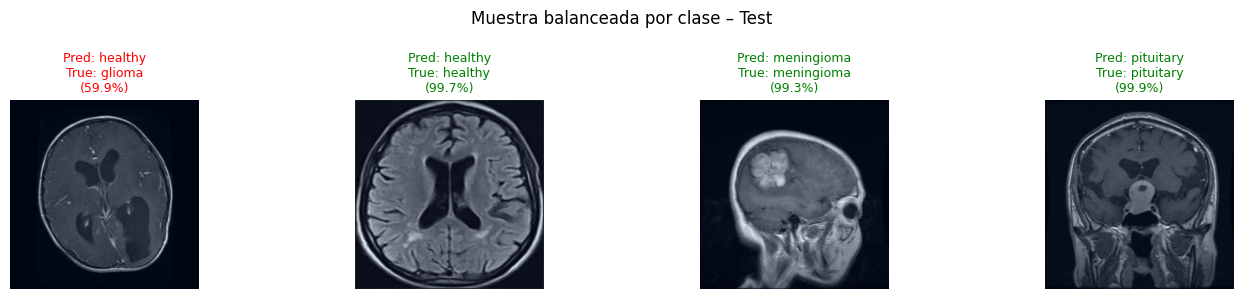

,idx_muestra,clase_real,clase_predicha,confianza
0,123,glioma,healthy,0.598655
1,523,healthy,healthy,0.996727
2,471,meningioma,meningioma,0.992953
3,44,pituitary,pituitary,0.998730


✅ Tabla guardada en: ./outputs/analysis/sample_balanced_table.csv


In [16]:

# @title Muestra balanceada por clase + DataFrame (pred vs real)
# -*- coding: utf-8 -*-
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))
y_proba = np.load(os.path.join(analysis_dir, "y_proba.npy"))

# 1 índice por clase real
sample_idxs = []
for c in range(len(class_names)):
    idxs_c = np.where(y_true == c)[0]
    if len(idxs_c) > 0:
        sample_idxs.append(int(random.choice(idxs_c)))

fig, axes = plt.subplots(1, len(sample_idxs), figsize=(14, 3))
for ax, idx in zip(axes, sample_idxs):
    img, _ = test_loader.dataset[idx]
    arr = img.permute(1, 2, 0).numpy()
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    pred_label = class_names[int(y_pred[idx])]
    true_label = class_names[int(y_true[idx])]
    conf = float(np.max(y_proba[idx])) * 100.0
    ax.imshow(arr); ax.axis("off")
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}\n({conf:.1f}%)",
                 color=("green" if pred_label == true_label else "red"), fontsize=9)
plt.suptitle("Muestra balanceada por clase – Test")
plt.tight_layout(); plt.show()

# Tabla comparativa
df = pd.DataFrame({
    "idx_muestra": sample_idxs,
    "clase_real":  [class_names[int(y_true[i])] for i in sample_idxs],
    "clase_predicha": [class_names[int(y_pred[i])] for i in sample_idxs],
    "confianza":   [float(np.max(y_proba[i])) for i in sample_idxs]
})
display(df)
df_path = os.path.join(analysis_dir, "sample_balanced_table.csv")
df.to_csv(df_path, index=False)
print("✅ Tabla guardada en:", df_path)


### 2.11. Grad-CAM (5 aleatorias + 1 por clase)
Este código aplica Grad-CAM para explicar visualmente las decisiones del modelo. Mapea qué regiones activan la predicción, permitiendo verificar si la red atiende zonas relevantes (p. ej., el tumor) y detectar atajos o sesgos. Usar la última capa convolucional de `layer4` en ResNet50 aporta señales semánticas ricas y localización suficiente. Las muestras aleatorias y por clase facilitan análisis de errores y evidencia cualitativa de interpretabilidad.


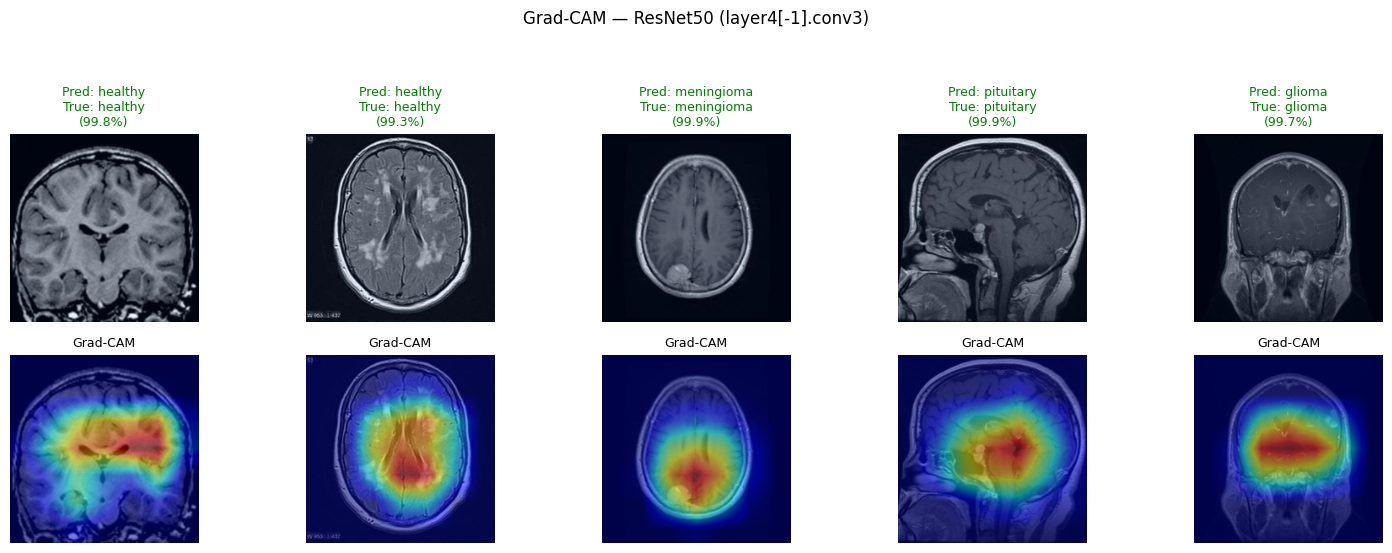

✅ Grad-CAM guardado en: ./outputs/analysis/random_test_gradcam.png


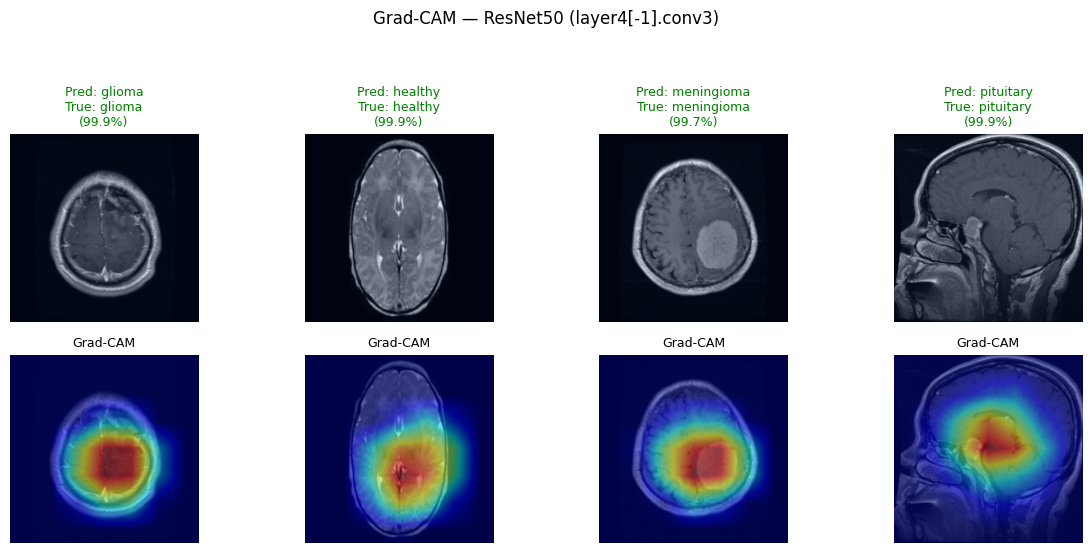

✅ Grad-CAM guardado en: ./outputs/analysis/classwise_gradcam.png


In [17]:

# @title Grad-CAM (ResNet50, layer4[-1].conv3) — aleatorias y por clase
# -*- coding: utf-8 -*-
def gradcam_on_indices(model: nn.Module, dataset: Subset, indices: list, save_path: str,
                       layer_attr: str = "layer4", block_idx: int = -1, conv_name: str = "conv3") -> None:
    """Genera mapas Grad-CAM para los índices dados y guarda una figura.

    Args:
      model: ResNet50 ya cargado con pesos y en eval().
      dataset: Subset del que se extraen las imágenes.
      indices: Lista de índices (int) sobre dataset para visualizar.
      save_path: Ruta de imagen salida.
      layer_attr: Atributo del módulo 'layer4'.
      block_idx: Índice del último bloque (por defecto -1).
      conv_name: Nombre del último conv dentro del bloque (conv3 en ResNet50).
    """
    model.eval()

    # Obtener capa objetivo
    target_layer = getattr(model, layer_attr)[block_idx]
    target_layer = getattr(target_layer, conv_name)

    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out.detach())

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    h_f = target_layer.register_forward_hook(fwd_hook)
    # full backward hook (más estable en PyTorch moderno)
    h_b = target_layer.register_full_backward_hook(bwd_hook)

    n = len(indices)
    rows = 2
    cols = n
    plt.figure(figsize=(3 * cols, 2.8 * rows))

    for i, idx in enumerate(indices):
        activations.clear(); gradients.clear()
        img, label = dataset[idx]
        H, W = img.shape[-2], img.shape[-1]
        inp = img.unsqueeze(0).to(cfg.device)

        logits = model(inp)
        pred = int(torch.argmax(logits, dim=1).item())
        conf = float(F.softmax(logits, dim=1).max().item()) * 100.0

        model.zero_grad(set_to_none=True)
        logits[0, pred].backward(retain_graph=True)

        acts = activations[-1]           # [1, C, h, w]
        grads = gradients[-1]            # [1, C, h, w]
        weights = grads.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = (weights * acts).sum(dim=1, keepdim=True) # [1, 1, h, w]
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam_up = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False)
        cam_up = cam_up.squeeze().detach().cpu().numpy()  # [H, W]

        # Preparar imagen en [0,1] y replicar a 3 canales si hace falta
        arr = img.permute(1, 2, 0).cpu().numpy()
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        if arr.shape[2] == 1:
            arr_rgb = np.repeat(arr, 3, axis=2)
        else:
            arr_rgb = arr

        heatmap = plt.cm.jet(cam_up)[..., :3]
        overlay = 0.5 * arr_rgb + 0.5 * heatmap
        overlay = np.clip(overlay, 0, 1)

        # Fila 1: imagen original; Fila 2: Grad-CAM
        plt.subplot(rows, cols, i + 1)
        plt.imshow(arr_rgb)
        plt.axis("off")
        color = "green" if pred == label else "red"
        plt.title(f"Pred: {class_names[pred]}\nTrue: {class_names[label]}\n({conf:.1f}%)",
                  color=color, fontsize=9)

        plt.subplot(rows, cols, i + 1 + cols)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title("Grad-CAM", fontsize=9)

    h_f.remove()
    h_b.remove()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.suptitle("Grad-CAM — ResNet50 (layer4[-1].conv3)")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Grad-CAM guardado en:", save_path)

# Cargar modelo mejor checkpoint
builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
grad_model = builder.build().to(cfg.device)
best_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
grad_model.load_state_dict(torch.load(best_path, map_location=cfg.device))
grad_model.eval()

# 5 aleatorias
rand_indices = random.sample(range(len(test_loader.dataset)), min(5, len(test_loader.dataset)))
gradcam_on_indices(grad_model, test_loader.dataset, rand_indices,
                   save_path=os.path.join(analysis_dir, "random_test_gradcam.png"))

# 1 por clase
classwise_indices = []
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
for c in range(len(class_names)):
    idxs_c = np.where(y_true == c)[0]
    if len(idxs_c) > 0:
        classwise_indices.append(int(random.choice(idxs_c)))
if classwise_indices:
    gradcam_on_indices(grad_model, test_loader.dataset, classwise_indices,
                       save_path=os.path.join(analysis_dir, "classwise_gradcam.png"))


### ***Fin del Note book***